# Commodities Market Outlook Datastream - Focus on Agri Commodities and Oil Impact 

In [1]:
#import libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

In [2]:
#import data
data = pd.read_excel('Cascade Research - CTW data.xlsx', sheet_name="DashBoard")

In [3]:
#Set date as datetime index 
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')


In [4]:
#View data structure
data.head()

,Time,Bloomberg Commodity Index,Brent Crude,Corn,Soybeans,Wheat,Arabica Coffee,Robusta Coffee,White Sugar
Date,,,,,,,,,
2025-04-25 15:45:00,2025-04-25 15:45:00,102.5323,66.28,4.8025,10.4950,5.3075,4.0355,5441.0,507.8
2025-04-25 15:40:00,2025-04-25 15:40:00,102.5778,66.21,4.8025,10.4975,5.3125,4.0525,5441.0,507.5
2025-04-25 15:35:00,2025-04-25 15:35:00,102.6003,66.29,4.8000,10.5000,5.3100,4.0525,5433.0,507.6
2025-04-25 15:30:00,2025-04-25 15:30:00,102.6061,66.34,4.8050,10.5075,5.3175,4.0670,5449.0,508.0
2025-04-25 15:25:00,2025-04-25 15:25:00,102.6197,66.33,4.8025,10.5100,5.3150,4.0810,5460.0,508.0


In [4]:
#Prepare for resampling 

#Set column name we will resample 
price_columns = [
    'Bloomberg Commodity Index',
    ' Brent Crude',  
    'Corn', 
    'Soybeans', 
    'Wheat',  
    'Arabica Coffee ', 
    'Robusta Coffee', 
    'White Sugar'   
]

print("DataFrame columns:")
print(data.columns.tolist())

DataFrame columns:
['Time', 'Bloomberg Commodity Index', ' Brent Crude', 'Corn', 'Soybeans', 'Wheat', 'Arabica Coffee ', 'Robusta Coffee', 'White Sugar']


In [5]:
#Resample intraday data -> take the last observation of each day 

#We save a backup of the original data 
data_backup = data.copy()

#Resample the data 
daily_closing_prices = data[price_columns].resample('D').last()

#Drop any days where no data exists 
daily_closing_prices = daily_closing_prices.dropna()

#Rebase all series to start at 100 
daily_closing_prices_rebased = daily_closing_prices / daily_closing_prices.iloc[1] * 100



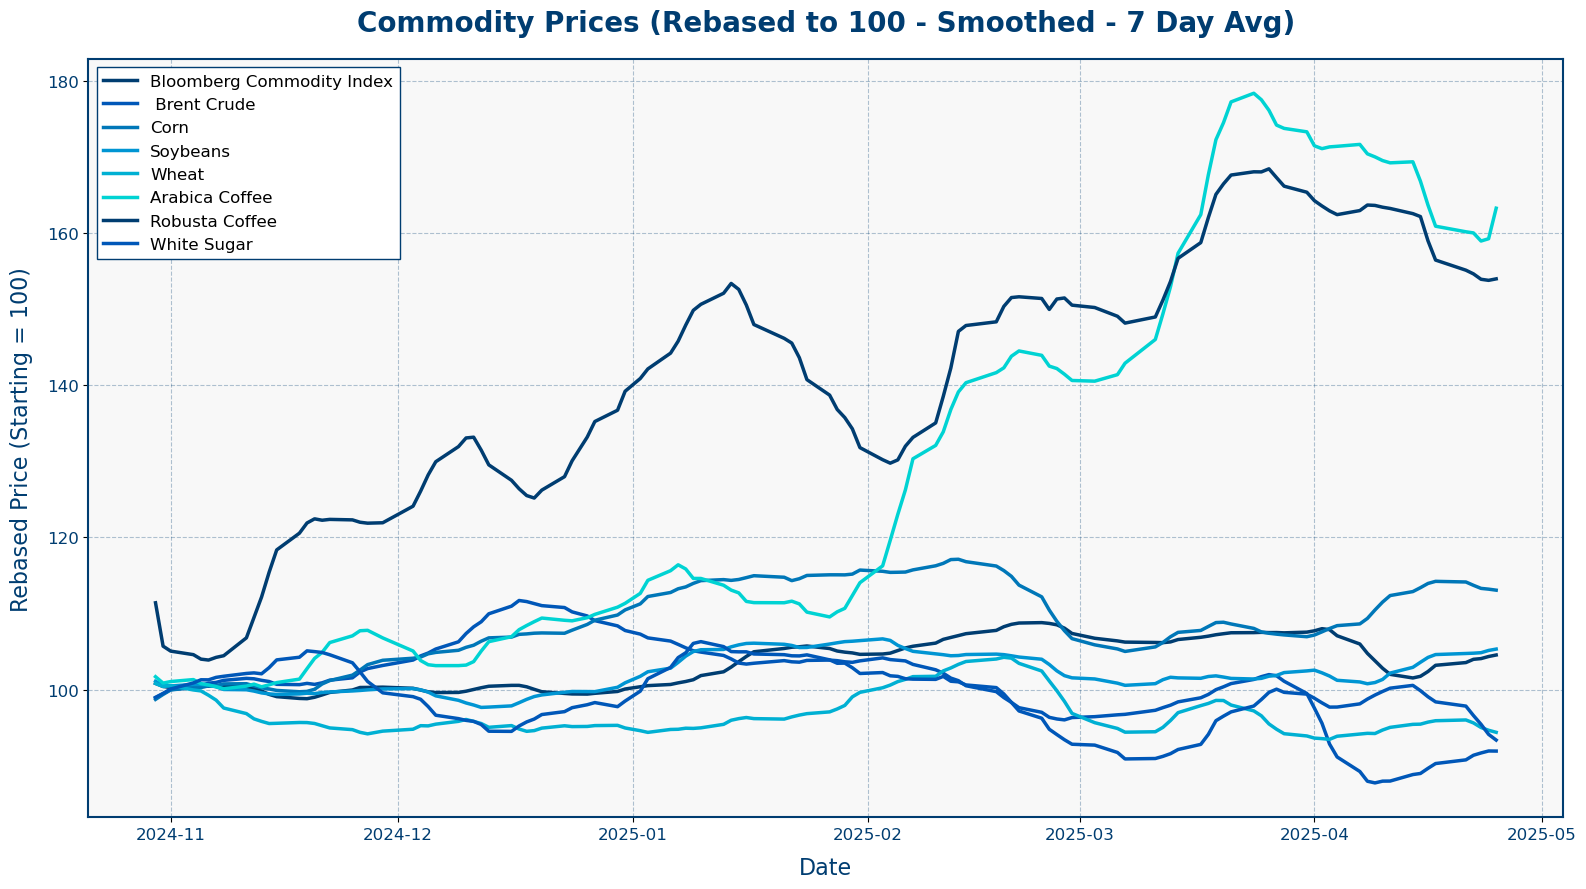

In [7]:
# Apply smoothing (7-day moving average)
ma_smooth = daily_closing_prices_rebased.rolling(window=7, min_periods=1).mean()

# Set McKinsey-style blue colors
mckinsey_blues = ['#003D71', '#0057B8', '#0077B8', '#0095D3', '#00B0D3', '#00D3D3']  # McKinsey's signature blues

# Create the figure with a white background
plt.figure(figsize=(16, 9), facecolor='white')

# Plot each line with McKinsey styling
for i, col in enumerate(ma_smooth.columns):
    plt.plot(ma_smooth.index, ma_smooth[col], 
             label=col, 
             linewidth=2.5,
             color=mckinsey_blues[i % len(mckinsey_blues)])  # Cycle through blues if more than 6 lines

# Formatting 
plt.title('Commodity Prices (Rebased to 100 - Smoothed - 7 Day Avg)', 
          fontsize=20, 
          fontweight='bold',
          pad=20,
          color='#003D71')  # Using McKinsey's dark blue for title

plt.xlabel('Date', 
           fontsize=16, 
           color='#003D71',
           labelpad=10)

plt.ylabel('Rebased Price (Starting = 100)', 
           fontsize=16, 
           color='#003D71',
           labelpad=10)

# Customize the legend
legend = plt.legend(fontsize=12, 
                    loc='upper left', 
                    frameon=True, 
                    fancybox=False,
                    edgecolor='#003D71',
                    framealpha=1)

# Customize the grid
plt.grid(True, 
         linestyle='--', 
         alpha=0.3, 
         color='#003D71')

# Customize the spines
for spine in plt.gca().spines.values():
    spine.set_color('#003D71')
    spine.set_linewidth(1.5)

# Customize the ticks
plt.xticks(fontsize=12, color='#003D71')
plt.yticks(fontsize=12, color='#003D71')

# Add a subtle background color
plt.gca().set_facecolor('#F8F8F8')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

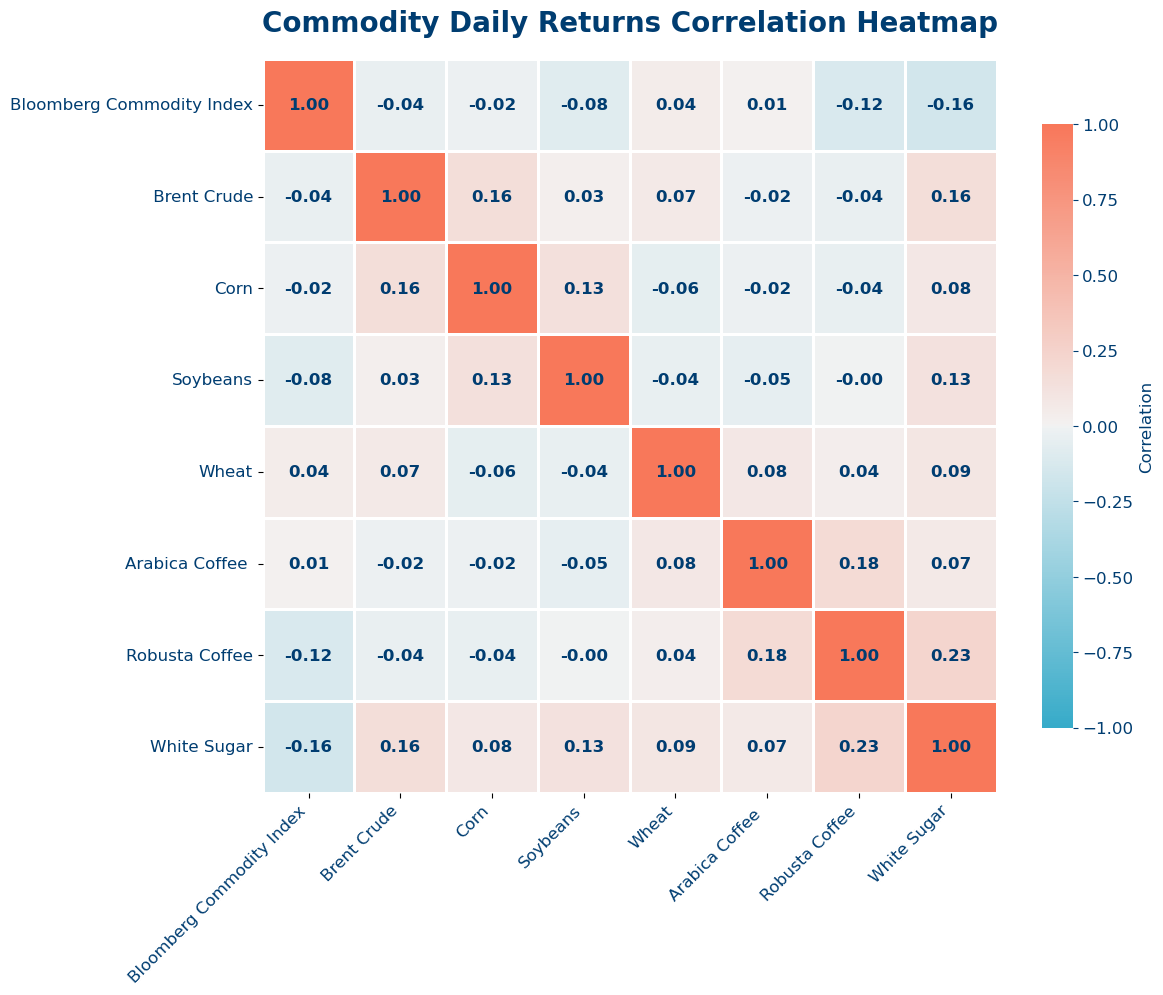

In [8]:
## Correlation Heatmap 

# Calculate daily returns
daily_returns = daily_closing_prices.pct_change().dropna()

# Compute correlation matrix
corr = daily_returns.corr()

# Initialize the figure with white background
plt.figure(figsize=(12, 10), facecolor='white')

# Generate a custom diverging colormap using McKinsey blues
cmap = sns.diverging_palette(220, 20, as_cmap=True, center='light', 
                            l=65, s=90)  # Adjusted for McKinsey-like colors

# Draw the heatmap
sns.heatmap(
    corr,
    annot=True, 
    cmap=cmap, 
    center=0, 
    fmt=".2f", 
    linewidths=1,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    annot_kws={"size": 12, "weight": 'bold', "color": '#003D71'},  # McKinsey blue for annotations
    square=True,
    vmin=-1, vmax=1  # Ensure full range of correlation
)

# Formatting
plt.title('Commodity Daily Returns Correlation Heatmap', 
          fontsize=20, 
          fontweight='bold', 
          pad=20,
          color='#003D71')  # McKinsey blue for title

# Customize ticks
plt.xticks(rotation=45, ha='right', fontsize=12, color='#003D71')
plt.yticks(rotation=0, fontsize=12, color='#003D71')

# Customize the colorbar
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize=12, colors='#003D71')
cbar.ax.set_ylabel('Correlation', fontsize=12, color='#003D71')

# Add a subtle background color
plt.gca().set_facecolor('#F8F8F8')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [9]:
#Log returns 
log_returns = np.log(daily_closing_prices / daily_closing_prices.shift(1)).dropna()

#Select Crude and agricultural commodities
selected_columns = [
    ' Brent Crude',  
    'Corn', 
    'Soybeans', 
    'Wheat',  
    'Arabica Coffee ', 
    'Robusta Coffee', 
    'White Sugar'   
]

#Check stationarity 
#Perform ADF test for each selected commodity
for column in selected_columns:
    adf_test = adfuller(log_returns[column])
    
    print(f'\nADF Test Results for {column}:')
    print('----------------------------------')
    print(f'ADF Statistic: {adf_test[0]:.4f}')
    print(f'p-value: {adf_test[1]:.4f}')
    print('Critical values:')
    for key, value in adf_test[4].items():
        print(f'\t{key}: {value:.4f}')
    
    # Add stationarity conclusion
    if adf_test[1] < 0.05:
        print(f'\nConclusion: The {column} data is STATIONARY (reject H0)')
    else:
        print(f'\nConclusion: The {column} data is NON-STATIONARY (fail to reject H0)')




ADF Test Results for  Brent Crude:
----------------------------------
ADF Statistic: -4.9102
p-value: 0.0000
Critical values:
	1%: -3.4891
	5%: -2.8872
	10%: -2.5805

Conclusion: The  Brent Crude data is STATIONARY (reject H0)

ADF Test Results for Corn:
----------------------------------
ADF Statistic: -9.5294
p-value: 0.0000
Critical values:
	1%: -3.4880
	5%: -2.8868
	10%: -2.5802

Conclusion: The Corn data is STATIONARY (reject H0)

ADF Test Results for Soybeans:
----------------------------------
ADF Statistic: -10.1606
p-value: 0.0000
Critical values:
	1%: -3.4880
	5%: -2.8868
	10%: -2.5802

Conclusion: The Soybeans data is STATIONARY (reject H0)

ADF Test Results for Wheat:
----------------------------------
ADF Statistic: -11.5614
p-value: 0.0000
Critical values:
	1%: -3.4880
	5%: -2.8868
	10%: -2.5802

Conclusion: The Wheat data is STATIONARY (reject H0)

ADF Test Results for Arabica Coffee :
----------------------------------
ADF Statistic: -10.3682
p-value: 0.0000
Critical v

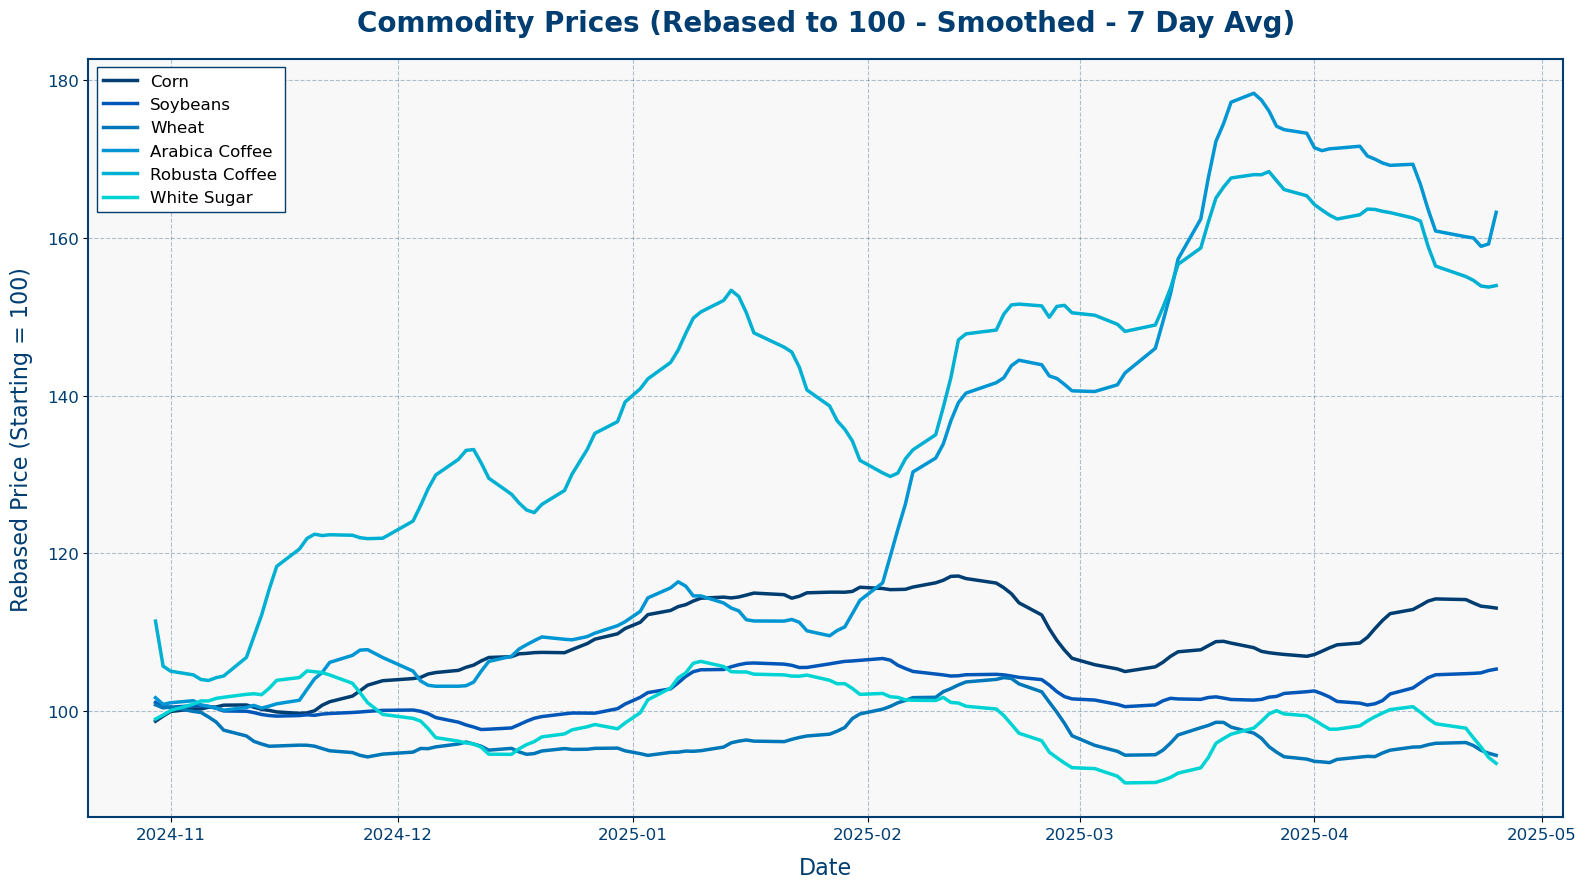

In [9]:
#Select Commodities to plot (excluding oil)
commodities_excluding_oil = [
    'Corn', 
    'Soybeans', 
    'Wheat',  
    'Arabica Coffee ', 
    'Robusta Coffee', 
    'White Sugar'
]

#Compute the 7-day moving average for Commodities 
ma_smooth_agri = daily_closing_prices_rebased[commodities_excluding_oil].rolling(window=7, min_periods=1).mean()

# Set McKinsey-style blue colors
mckinsey_blues = ['#003D71', '#0057B8', '#0077B8', '#0095D3', '#00B0D3', '#00D3D3']  # McKinsey's signature blues

# Create the figure with a white background
plt.figure(figsize=(16, 9), facecolor='white')

# Plot each line with McKinsey styling
for i, col in enumerate(ma_smooth_agri.columns):
    plt.plot(ma_smooth_agri.index, ma_smooth_agri[col], 
             label=col, 
             linewidth=2.5,
             color=mckinsey_blues[i % len(mckinsey_blues)])  # Cycle through blues if more than 6 lines

# Formatting 
plt.title('Commodity Prices (Rebased to 100 - Smoothed - 7 Day Avg)', 
          fontsize=20, 
          fontweight='bold',
          pad=20,
          color='#003D71')  # Using McKinsey's dark blue for title

plt.xlabel('Date', 
           fontsize=16, 
           color='#003D71',
           labelpad=10)

plt.ylabel('Rebased Price (Starting = 100)', 
           fontsize=16, 
           color='#003D71',
           labelpad=10)

# Customize the legend
legend = plt.legend(fontsize=12, 
                    loc='upper left', 
                    frameon=True, 
                    fancybox=False,
                    edgecolor='#003D71',
                    framealpha=1)

# Customize the grid
plt.grid(True, 
         linestyle='--', 
         alpha=0.3, 
         color='#003D71')

# Customize the spines
for spine in plt.gca().spines.values():
    spine.set_color('#003D71')
    spine.set_linewidth(1.5)

# Customize the ticks
plt.xticks(fontsize=12, color='#003D71')
plt.yticks(fontsize=12, color='#003D71')

# Add a subtle background color
plt.gca().set_facecolor('#F8F8F8')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

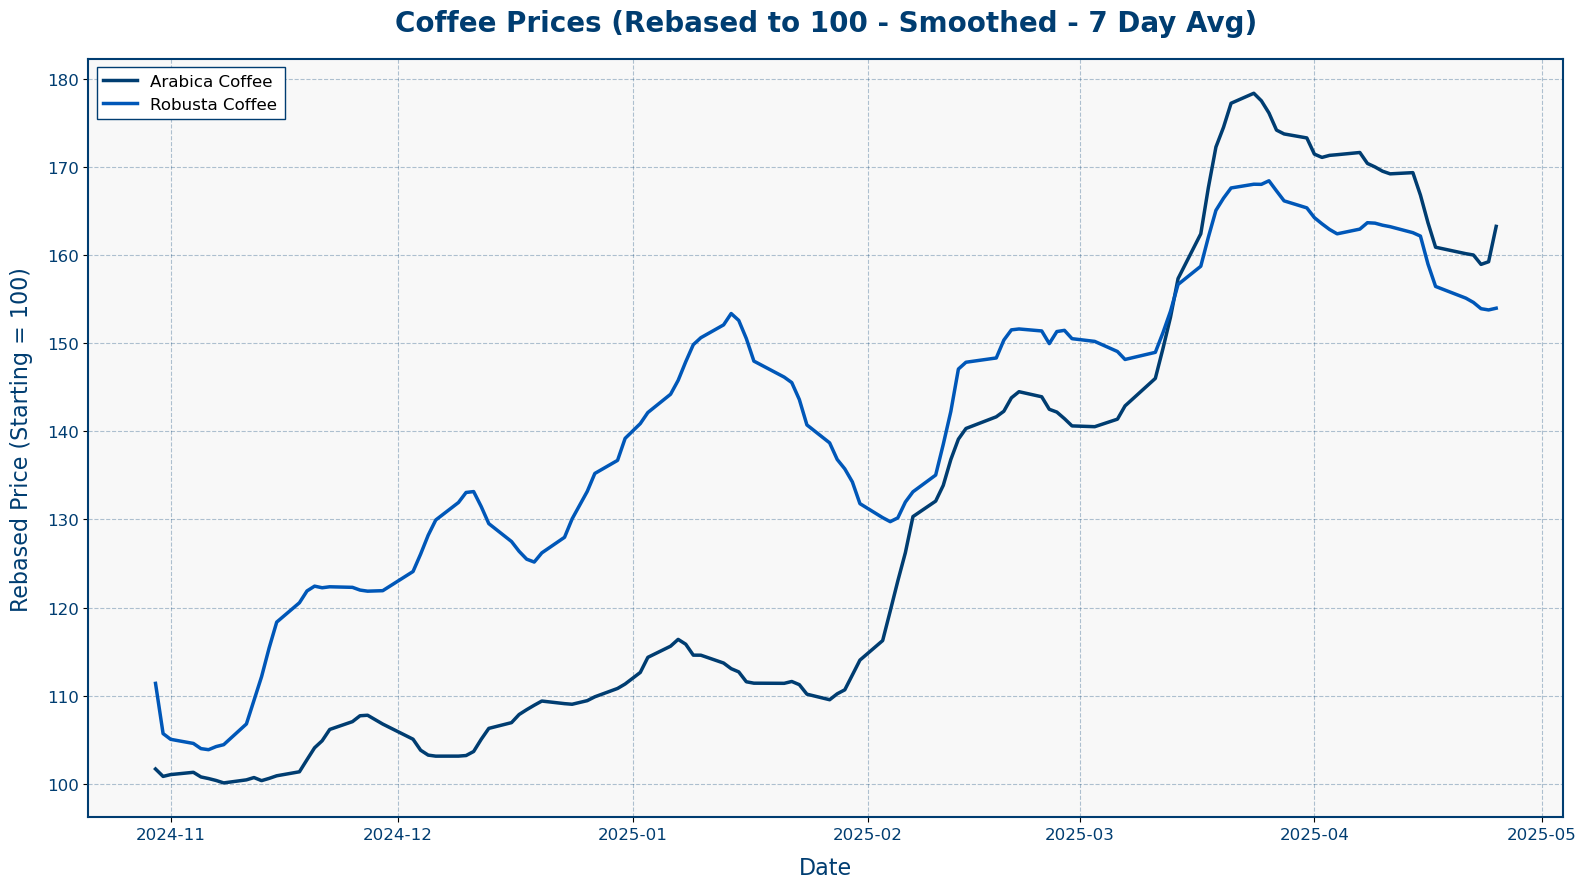

In [10]:
#Select Only Coffee to plot
only_coffee = [
    'Arabica Coffee ', 
    'Robusta Coffee'
]

#Compute the 7-day moving average for Coffee 
ma_smooth_coffee = daily_closing_prices_rebased[only_coffee].rolling(window=7, min_periods=1).mean()

# Set McKinsey-style blue colors
mckinsey_blues = ['#003D71', '#0057B8']  # McKinsey's signature blues for two lines

# Create the figure with a white background
plt.figure(figsize=(16, 9), facecolor='white')

# Plot each line with McKinsey styling
for i, col in enumerate(ma_smooth_coffee.columns):
    plt.plot(ma_smooth_coffee.index, ma_smooth_coffee[col], 
             label=col, 
             linewidth=2.5,
             color=mckinsey_blues[i])

# Formatting 
plt.title('Coffee Prices (Rebased to 100 - Smoothed - 7 Day Avg)', 
          fontsize=20, 
          fontweight='bold',
          pad=20,
          color='#003D71')  # Using McKinsey's dark blue for title

plt.xlabel('Date', 
           fontsize=16, 
           color='#003D71',
           labelpad=10)

plt.ylabel('Rebased Price (Starting = 100)', 
           fontsize=16, 
           color='#003D71',
           labelpad=10)

# Customize the legend
legend = plt.legend(fontsize=12, 
                    loc='upper left', 
                    frameon=True, 
                    fancybox=False,
                    edgecolor='#003D71',
                    framealpha=1)

# Customize the grid
plt.grid(True, 
         linestyle='--', 
         alpha=0.3, 
         color='#003D71')

# Customize the spines
for spine in plt.gca().spines.values():
    spine.set_color('#003D71')
    spine.set_linewidth(1.5)

# Customize the ticks
plt.xticks(fontsize=12, color='#003D71')
plt.yticks(fontsize=12, color='#003D71')

# Add a subtle background color
plt.gca().set_facecolor('#F8F8F8')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

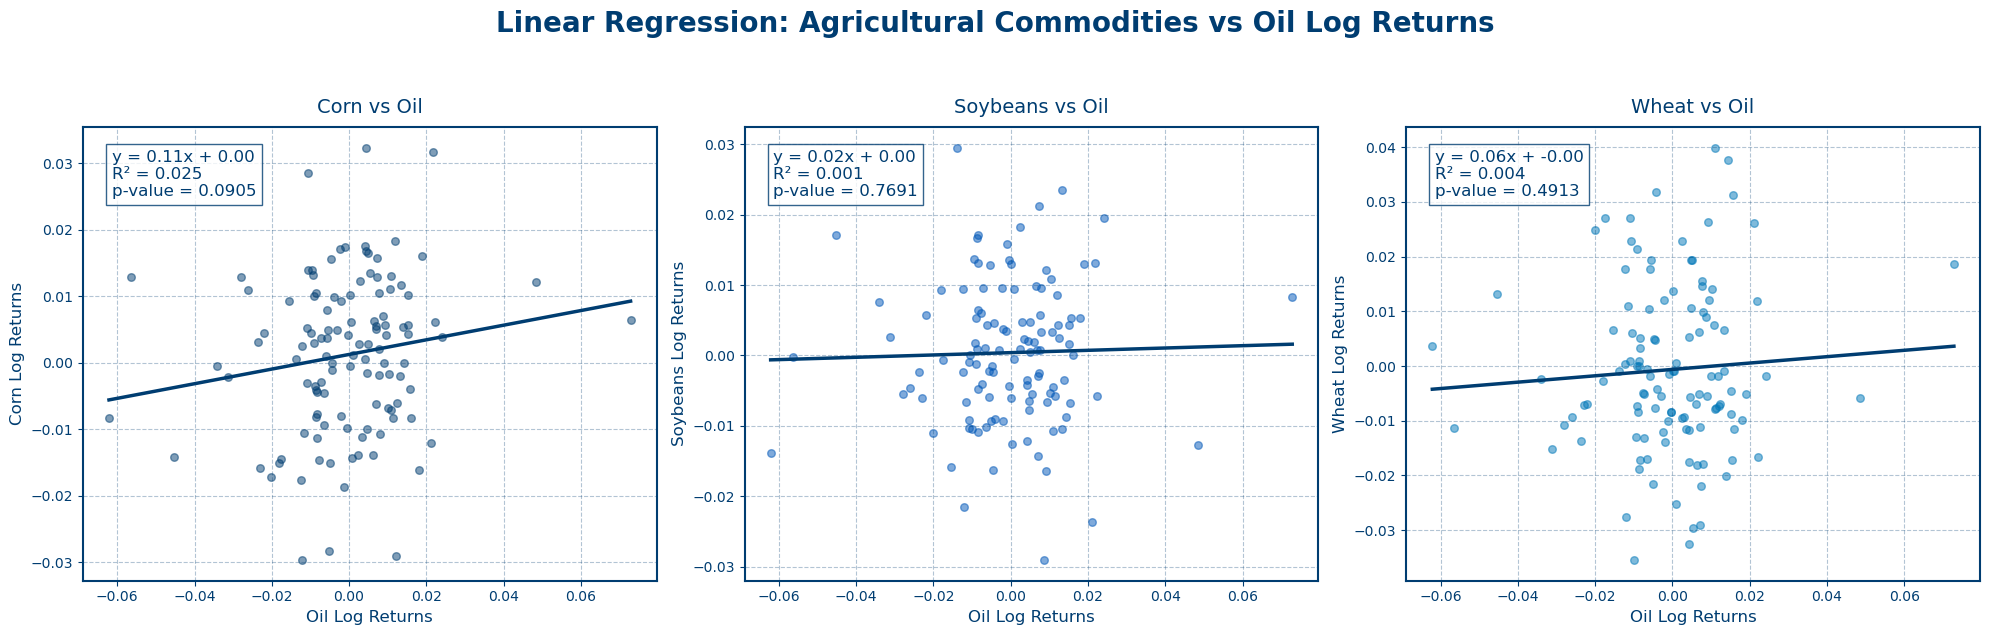


Detailed Regression Results:
--------------------------------------------------

Corn vs Oil:
Coefficient (slope): 0.1100
Intercept: 0.0012
R-squared: 0.0247
P-value: 0.0905
--------------------------------------------------

Soybeans vs Oil:
Coefficient (slope): 0.0165
Intercept: 0.0004
R-squared: 0.0008
P-value: 0.7691
--------------------------------------------------

Wheat vs Oil:
Coefficient (slope): 0.0582
Intercept: -0.0006
R-squared: 0.0041
P-value: 0.4913
--------------------------------------------------


In [19]:
# Import necessary library
from sklearn.linear_model import LinearRegression
from scipy import stats

# Calculate log returns
log_returns = np.log(daily_closing_prices / daily_closing_prices.shift(1)).dropna()

# Prepare the data for regression
regression_data = log_returns[[' Brent Crude', 'Corn', 'Soybeans', 'Wheat']].copy()

# Create subplots for each agricultural commodity
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Linear Regression: Agricultural Commodities vs Oil Log Returns', 
             fontsize=20, 
             fontweight='bold',
             color='#003D71',
             y=1.05)

# Set McKinsey-style colors
mckinsey_blues = ['#003D71', '#0057B8', '#0077B8']

# Perform regression for each agricultural commodity
for idx, (commodity, color) in enumerate(zip(['Corn', 'Soybeans', 'Wheat'], mckinsey_blues)):
    # Prepare data for regression
    X = regression_data[' Brent Crude'].values.reshape(-1, 1)
    y = regression_data[commodity].values
    
    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)
    
    # Calculate R-squared
    r_squared = model.score(X, y)
    
    # Calculate p-value
    n = len(X)
    p = 1  # number of predictors
    df = n - p - 1  # degrees of freedom
    
    # Calculate t-statistic and p-value
    y_pred = model.predict(X)
    mse = np.sum((y - y_pred) ** 2) / df
    var_b = mse * (np.linalg.inv(np.dot(X.T, X)).diagonal())
    sd_b = np.sqrt(var_b)
    t_stat = model.coef_ / sd_b
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))
    
    # Generate predictions for the line
    X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_line = model.predict(X_line)
    
    # Create scatter plot with regression line
    axes[idx].scatter(X, y, 
                     color=color, 
                     alpha=0.5, 
                     s=30)
    
    axes[idx].plot(X_line, y_line, 
                   color='#003D71', 
                   linewidth=2.5)
    
    # Add regression equation, R-squared, and p-value
    equation = f'y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}'
    r2_text = f'R² = {r_squared:.3f}'
    p_text = f'p-value = {p_value[0]:.4f}'
    
    axes[idx].text(0.05, 0.95, 
                   f'{equation}\n{r2_text}\n{p_text}', 
                   transform=axes[idx].transAxes,
                   fontsize=12,
                   color='#003D71',
                   verticalalignment='top',
                   bbox=dict(facecolor='white', 
                           edgecolor='#003D71',
                           alpha=0.8))
    
    # Customize subplot
    axes[idx].set_title(f'{commodity} vs Oil',
                       fontsize=14,
                       color='#003D71',
                       pad=10)
    axes[idx].set_xlabel('Oil Log Returns',
                        fontsize=12,
                        color='#003D71')
    axes[idx].set_ylabel(f'{commodity} Log Returns',
                        fontsize=12,
                        color='#003D71')
    
    # Customize grid
    axes[idx].grid(True, 
                  linestyle='--', 
                  alpha=0.3, 
                  color='#003D71')
    
    # Customize ticks
    axes[idx].tick_params(colors='#003D71')
    
    # Customize spines
    for spine in axes[idx].spines.values():
        spine.set_color('#003D71')
        spine.set_linewidth(1.5)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# Print detailed regression results
print("\nDetailed Regression Results:")
print("-" * 50)
for commodity in ['Corn', 'Soybeans', 'Wheat']:
    X = regression_data[' Brent Crude'].values.reshape(-1, 1)
    y = regression_data[commodity].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    # Calculate p-value
    n = len(X)
    p = 1  # number of predictors
    df = n - p - 1  # degrees of freedom
    
    # Calculate t-statistic and p-value
    y_pred = model.predict(X)
    mse = np.sum((y - y_pred) ** 2) / df
    var_b = mse * (np.linalg.inv(np.dot(X.T, X)).diagonal())
    sd_b = np.sqrt(var_b)
    t_stat = model.coef_ / sd_b
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))
    
    print(f"\n{commodity} vs Oil:")
    print(f"Coefficient (slope): {model.coef_[0]:.4f}")
    print(f"Intercept: {model.intercept_:.4f}")
    print(f"R-squared: {model.score(X, y):.4f}")
    print(f"P-value: {p_value[0]:.4f}")
    print("-" * 50)

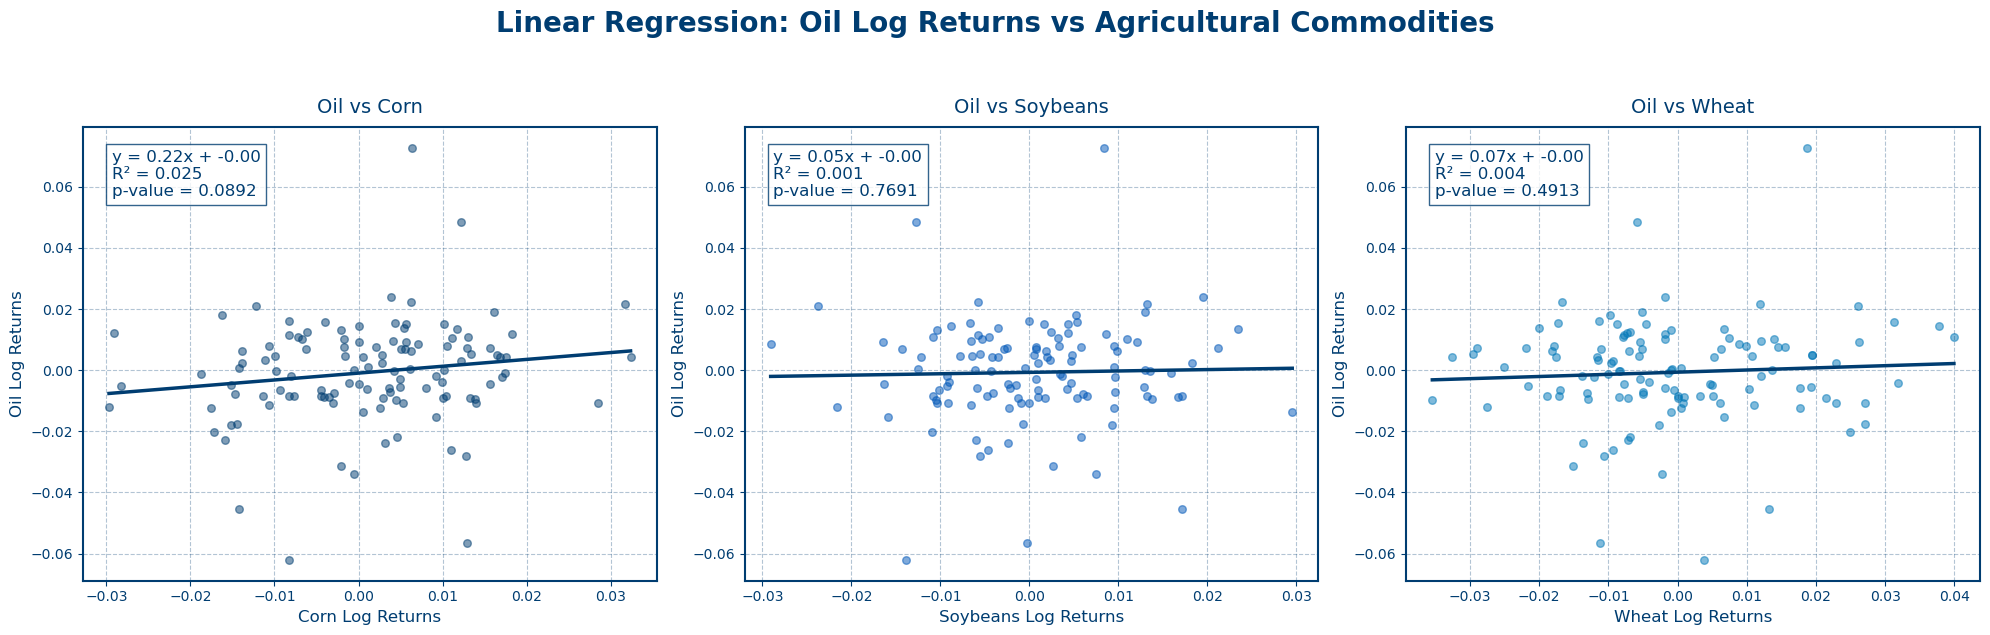


Detailed Regression Results:
--------------------------------------------------

Oil vs Corn:
Coefficient (slope): 0.2242
Intercept: -0.0010
R-squared: 0.0247
P-value: 0.0892
--------------------------------------------------

Oil vs Soybeans:
Coefficient (slope): 0.0456
Intercept: -0.0007
R-squared: 0.0008
P-value: 0.7691
--------------------------------------------------

Oil vs Wheat:
Coefficient (slope): 0.0708
Intercept: -0.0006
R-squared: 0.0041
P-value: 0.4913
--------------------------------------------------


In [20]:
# Prepare the data for regression
regression_data = log_returns[[' Brent Crude', 'Corn', 'Soybeans', 'Wheat']].copy()

# Create subplots for each agricultural commodity
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Linear Regression: Oil Log Returns vs Agricultural Commodities', 
             fontsize=20, 
             fontweight='bold',
             color='#003D71',
             y=1.05)

# Set McKinsey-style colors
mckinsey_blues = ['#003D71', '#0057B8', '#0077B8']

# Perform regression for each agricultural commodity
for idx, (commodity, color) in enumerate(zip(['Corn', 'Soybeans', 'Wheat'], mckinsey_blues)):
    # Prepare data for regression
    X = regression_data[commodity].values.reshape(-1, 1)
    y = regression_data[' Brent Crude'].values
    
    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)
    
    # Calculate R-squared
    r_squared = model.score(X, y)
    
    # Calculate p-value
    n = len(X)
    p = 1  # number of predictors
    df = n - p - 1  # degrees of freedom
    
    # Calculate t-statistic and p-value
    y_pred = model.predict(X)
    mse = np.sum((y - y_pred) ** 2) / df
    var_b = mse * (np.linalg.inv(np.dot(X.T, X)).diagonal())
    sd_b = np.sqrt(var_b)
    t_stat = model.coef_ / sd_b
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))
    
    # Generate predictions for the line
    X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_line = model.predict(X_line)
    
    # Create scatter plot with regression line
    axes[idx].scatter(X, y, 
                     color=color, 
                     alpha=0.5, 
                     s=30)
    
    axes[idx].plot(X_line, y_line, 
                   color='#003D71', 
                   linewidth=2.5)
    
    # Add regression equation, R-squared, and p-value
    equation = f'y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}'
    r2_text = f'R² = {r_squared:.3f}'
    p_text = f'p-value = {p_value[0]:.4f}'
    
    axes[idx].text(0.05, 0.95, 
                   f'{equation}\n{r2_text}\n{p_text}', 
                   transform=axes[idx].transAxes,
                   fontsize=12,
                   color='#003D71',
                   verticalalignment='top',
                   bbox=dict(facecolor='white', 
                           edgecolor='#003D71',
                           alpha=0.8))
    
    # Customize subplot
    axes[idx].set_title(f'Oil vs {commodity}',
                       fontsize=14,
                       color='#003D71',
                       pad=10)
    axes[idx].set_xlabel(f'{commodity} Log Returns',
                        fontsize=12,
                        color='#003D71')
    axes[idx].set_ylabel('Oil Log Returns',
                        fontsize=12,
                        color='#003D71')
    
    # Customize grid
    axes[idx].grid(True, 
                  linestyle='--', 
                  alpha=0.3, 
                  color='#003D71')
    
    # Customize ticks
    axes[idx].tick_params(colors='#003D71')
    
    # Customize spines
    for spine in axes[idx].spines.values():
        spine.set_color('#003D71')
        spine.set_linewidth(1.5)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# Print detailed regression results
print("\nDetailed Regression Results:")
print("-" * 50)
for commodity in ['Corn', 'Soybeans', 'Wheat']:
    X = regression_data[commodity].values.reshape(-1, 1)
    y = regression_data[' Brent Crude'].values
    
    model = LinearRegression()
    model.fit(X, y)
    
    # Calculate p-value
    n = len(X)
    p = 1  # number of predictors
    df = n - p - 1  # degrees of freedom
    
    # Calculate t-statistic and p-value
    y_pred = model.predict(X)
    mse = np.sum((y - y_pred) ** 2) / df
    var_b = mse * (np.linalg.inv(np.dot(X.T, X)).diagonal())
    sd_b = np.sqrt(var_b)
    t_stat = model.coef_ / sd_b
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))
    
    print(f"\nOil vs {commodity}:")
    print(f"Coefficient (slope): {model.coef_[0]:.4f}")
    print(f"Intercept: {model.intercept_:.4f}")
    print(f"R-squared: {model.score(X, y):.4f}")
    print(f"P-value: {p_value[0]:.4f}")
    print("-" * 50)

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


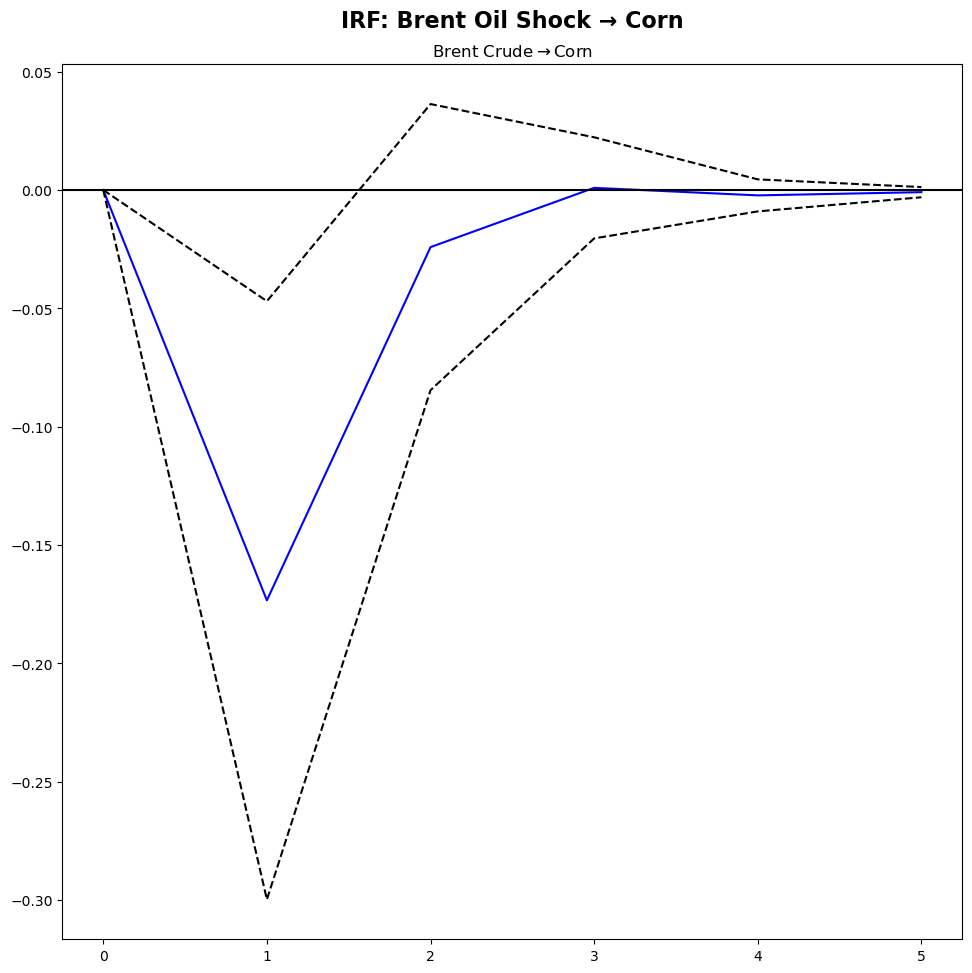

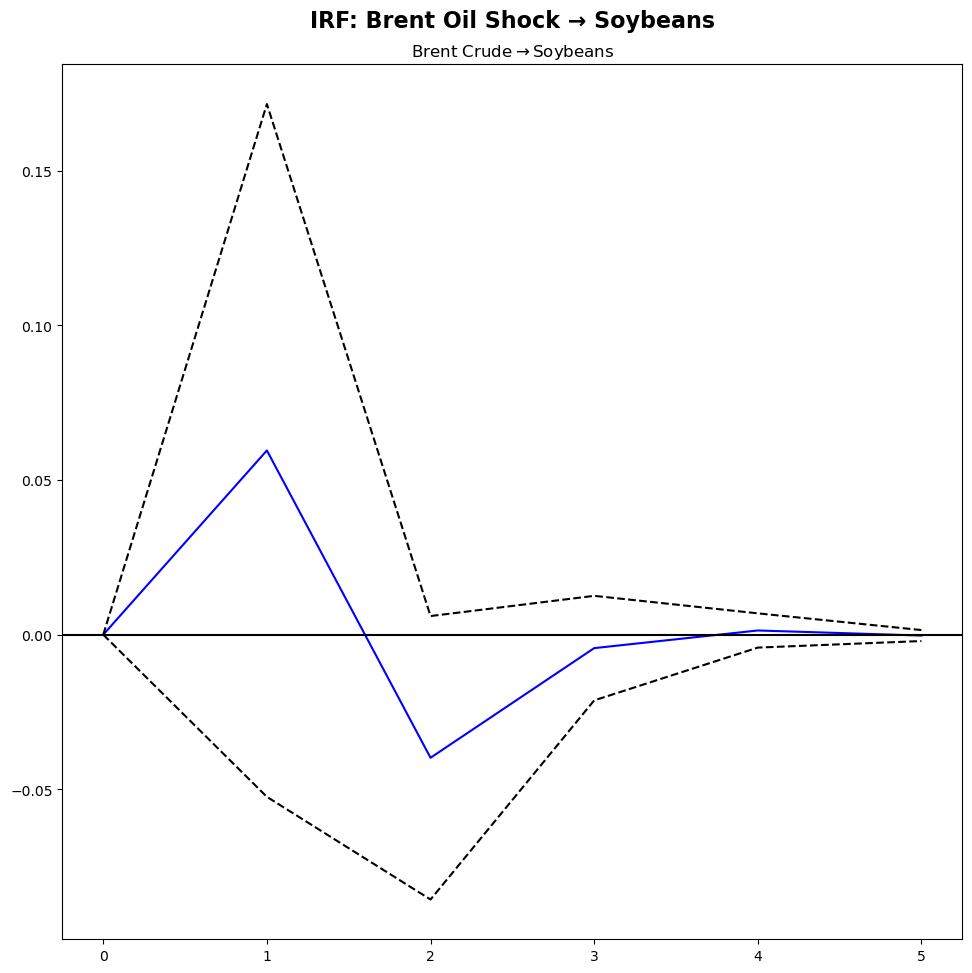

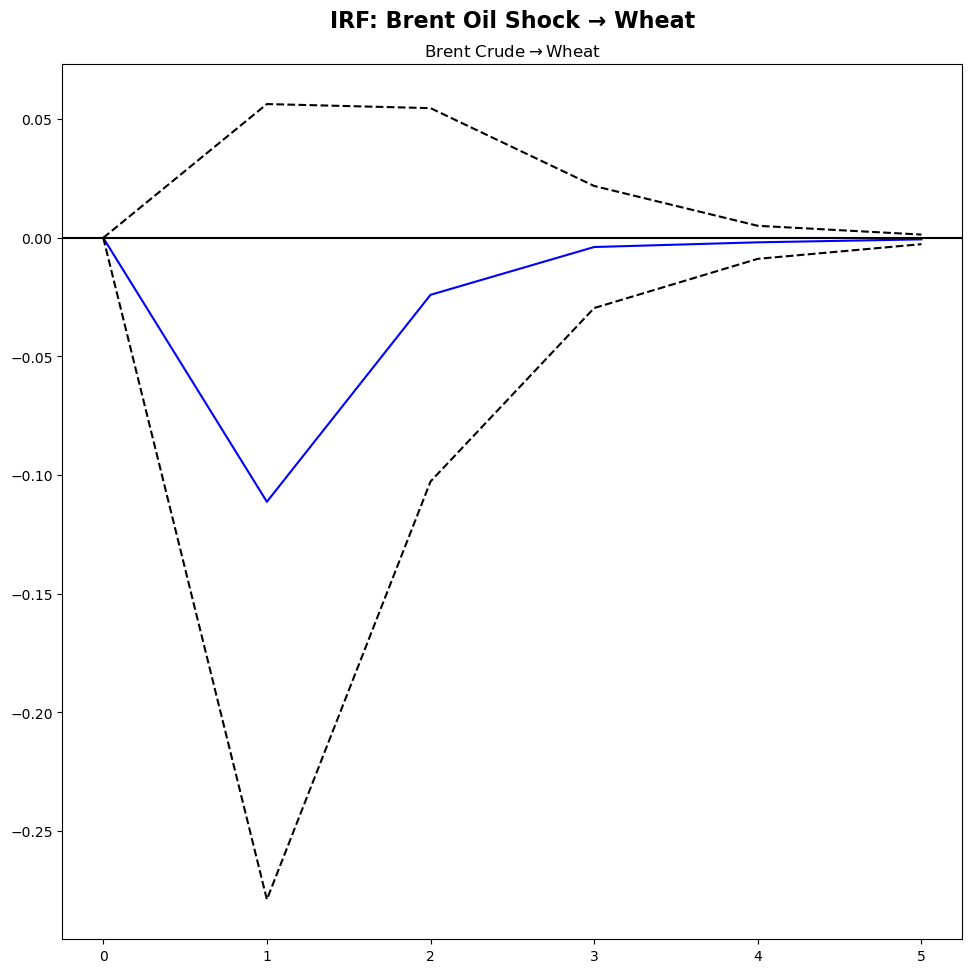

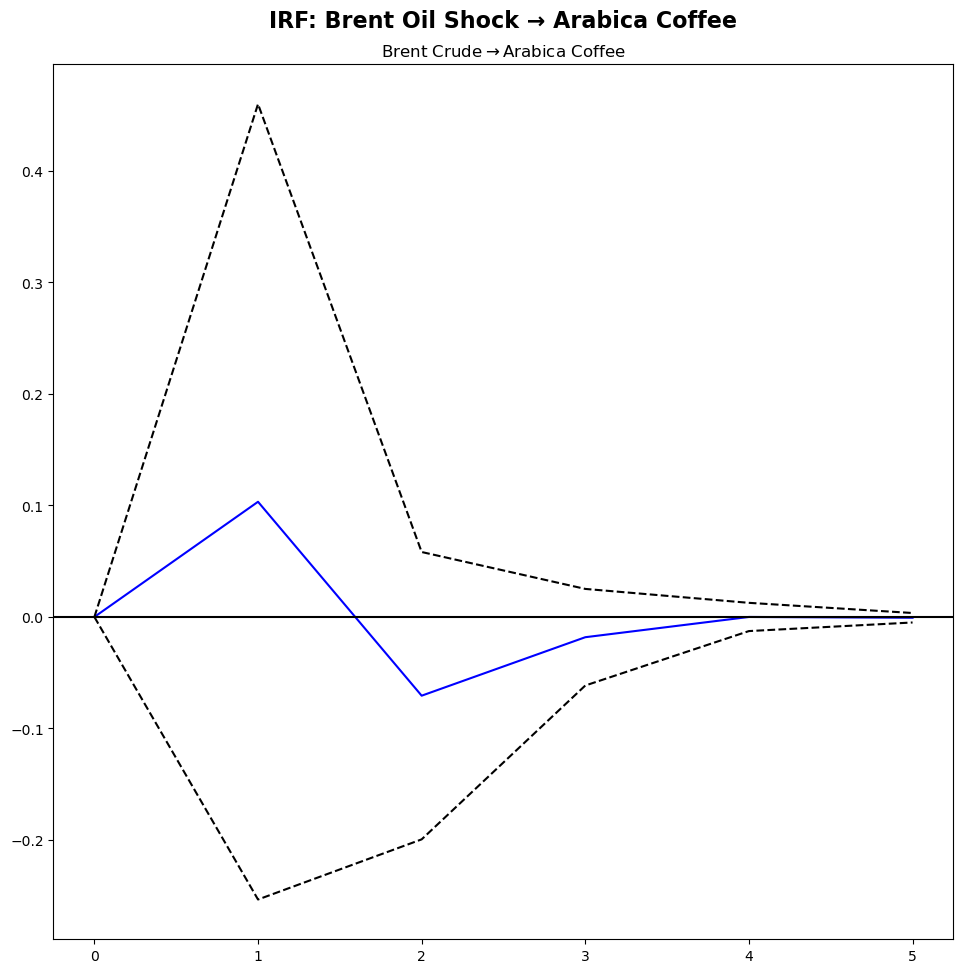

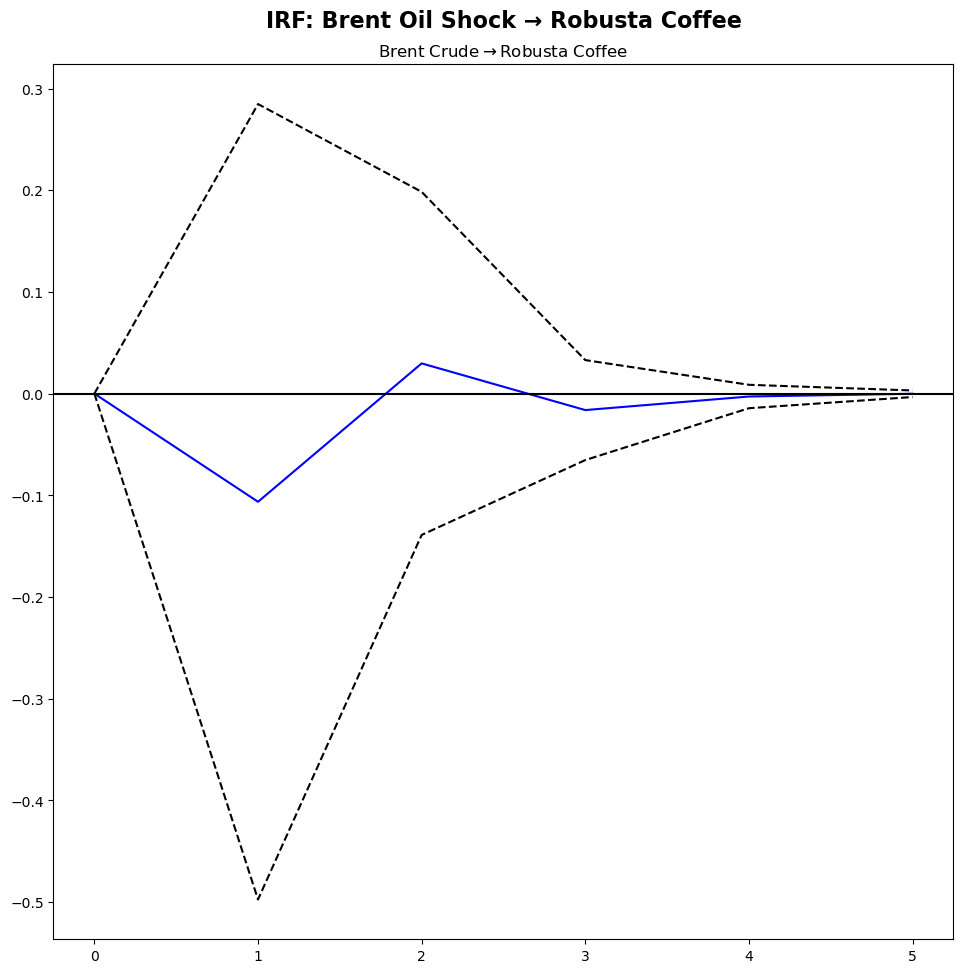

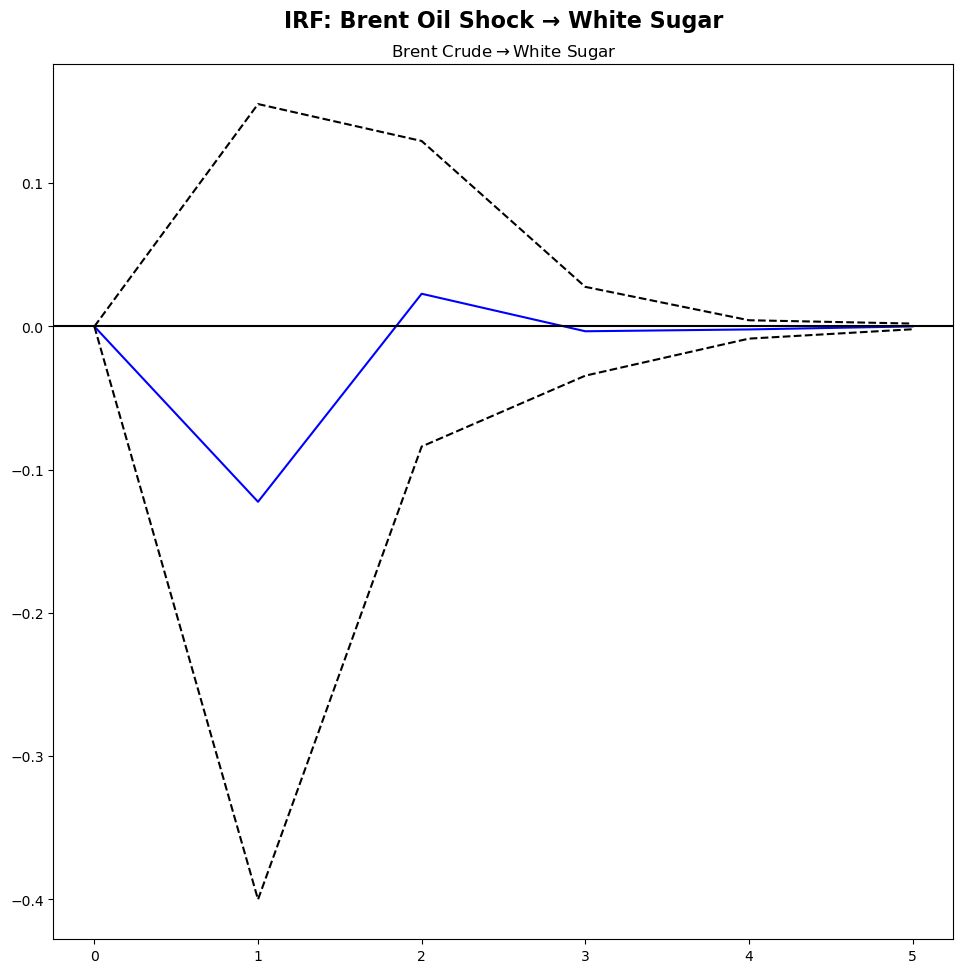

In [38]:
from statsmodels.tsa.api import VAR

log_returns.columns = log_returns.columns.str.strip()

#Select variables to fit model 
var_model = log_returns[[
    'Brent Crude',
    'Corn', 
    'Soybeans', 
    'Wheat',  
    'Arabica Coffee', 
    'Robusta Coffee', 
    'White Sugar'
]]


#Create VAR model 

model = VAR(var_model)

#Select optimal lags
lag_order = model.select_order(maxlags=10)
optimal_lag = 1

#Fit model 
results = model.fit(optimal_lag) 

#Generate IRF (5 days ahead)
irf = results.irf(5)

responses = ['Corn', 'Soybeans', 'Wheat', 'Arabica Coffee', 'Robusta Coffee', 'White Sugar']

for response_var in responses:
    irf.plot(impulse='Brent Crude', response=response_var)
    plt.suptitle(f'IRF: Brent Oil Shock → {response_var}', fontsize=16, fontweight='bold')
    plt.show()